# 05 — Improved Models: Character N-Gram TF-IDF + LightGBM

This notebook replaces the 26-dimensional letter-frequency baseline with a **character n-gram TF-IDF** feature space and trains **LightGBM** classifiers for both Gender and Race prediction.

## Why this approach?

The baseline (notebooks 02 & 03) encodes each name as 26 letter counts. This discards **order** entirely — `"Maria"` and `"Riama"` produce identical vectors. Character n-grams fix this:

| Feature set | What it captures | Example features |
|---|---|---|
| Letter counts (baseline) | Which letters appear | `a=2, m=1, r=1, i=1` |
| Char bigrams | Adjacent letter pairs | `ma`, `ar`, `ri`, `ia` |
| Char trigrams | 3-letter substrings | `mar`, `ari`, `ria` |
| Char 4-grams | 4-letter substrings | `mari`, `aria` |

TF-IDF weighting down-weights very common substrings (e.g. `"th"`, `"an"`) and amplifies discriminative ones (e.g. `"ita"`, `"ez"`).  
LightGBM handles the resulting **sparse, high-dimensional** matrix efficiently with gradient boosting.

## Expected improvement
- Gender: baseline ~77–78% → target ~83–87%
- Race: baseline ~82–84% → target ~87–91% (especially for minority classes)

## Saved artefacts
All artefacts go into `models/`:

| File | Description |
|---|---|
| `gender_tfidf_vectorizer.pkl` | Fitted `TfidfVectorizer` for first names |
| `gender_lgbm_model.pkl` | LightGBM gender classifier |
| `race_tfidf_vectorizer.pkl` | Fitted `TfidfVectorizer` for surnames |
| `race_lgbm_model.pkl` | LightGBM race classifier |
| `race_label_encoder.pkl` | `LabelEncoder` for race classes (shared with RF pipeline) |

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE       = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED  = os.path.join(BASE, 'data', 'processed')
MODELS_DIR = os.path.join(BASE, 'models')

RANDOM_SEED = 42
print('LightGBM version :', lgb.__version__)
print('Base dir         :', BASE)

LightGBM version : 4.6.0
Base dir         : /Volumes/Local Disk/CBBM Momin/NameDemographics-ML


---
# Part A — Gender Prediction

## A1. Load Gender Data

In [2]:
gender_df = pd.read_csv(os.path.join(PROCESSED, 'Unique_Names_Till_2021.csv'))
gender_df.columns = [c.strip() for c in gender_df.columns]

name_col   = [c for c in gender_df.columns if c.lower() in ('name', 'firstname', 'first_name')][0]
gender_col = [c for c in gender_df.columns if c.lower() in ('gender', 'sex')][0]

# Clean: lowercase names, drop nulls
gender_df = gender_df.dropna(subset=[name_col, gender_col])
gender_df[name_col] = gender_df[name_col].str.lower().str.strip()

print(f'Rows: {len(gender_df):,}')
print('Class distribution:')
print(gender_df[gender_col].value_counts())

Rows: 101,338
Class distribution:
F    63751
M    37587
Name: Gender, dtype: int64


## A2. Character N-Gram TF-IDF Features

In [3]:
# TfidfVectorizer settings
# analyzer='char_wb' : adds word-boundary padding (' maria ') so start/end patterns
#                      are treated as distinct from mid-word patterns
# ngram_range=(2,4)  : capture di-, tri-, and 4-grams
# max_features=8000  : keeps memory manageable while retaining most signal
# min_df=2           : ignore substrings that appear in only one name
# sublinear_tf=True  : apply 1 + log(tf) smoothing to reduce domination by long names

gender_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=8000,
    min_df=2,
    sublinear_tf=True,
)

names  = gender_df[name_col].values
labels = gender_df[gender_col].values

X_gender = gender_vectorizer.fit_transform(names)   # sparse matrix

print(f'Feature matrix  : {X_gender.shape}  (sparse)')
print(f'Non-zero entries: {X_gender.nnz:,}  ({X_gender.nnz / (X_gender.shape[0] * X_gender.shape[1]) * 100:.2f}% dense)')

# Show the most informative n-grams for each class
feature_names = gender_vectorizer.get_feature_names_out()
print(f'\nSample n-gram features: {feature_names[:10]}')

Feature matrix  : (101338, 8000)  (sparse)
Non-zero entries: 1,766,554  (0.22% dense)

Sample n-gram features: [' a' ' aa' ' aad' ' aal' ' aam' ' aar' ' aas' ' ab' ' abb' ' abd']


In [4]:
# Top 20 n-grams by mean TF-IDF per gender
X_dense  = X_gender.toarray()
mask_F   = labels == 'F'
mask_M   = labels == 'M'

mean_F = X_dense[mask_F].mean(axis=0)
mean_M = X_dense[mask_M].mean(axis=0)

# Discriminative score: how much higher is the mean TF-IDF for F vs M (and vice versa)
diff_F = mean_F - mean_M
diff_M = mean_M - mean_F

top20_F = [feature_names[i] for i in np.argsort(diff_F)[-20:][::-1]]
top20_M = [feature_names[i] for i in np.argsort(diff_M)[-20:][::-1]]

print('Top 20 n-grams most associated with  F:', top20_F)
print('\nTop 20 n-grams most associated with  M:', top20_M)

Top 20 n-grams most associated with  F: ['a ', 'na', 'na ', 'ia ', 'ia', 'nn', 'e ', 'ya', 'la', 'ne', 'ah ', 'ly', 'li', 'ha ', 'ra ', 'le', 'ni', 'la ', 'sha', 'sh']

Top 20 n-grams most associated with  M: ['n ', 'on ', 'on', 'an ', 'r ', 's ', 'o ', 'l ', 'd ', 'er ', 'en ', 'us', 'io', 'k ', 'el ', 'us ', 'er', 'm ', ' j', 'in ']


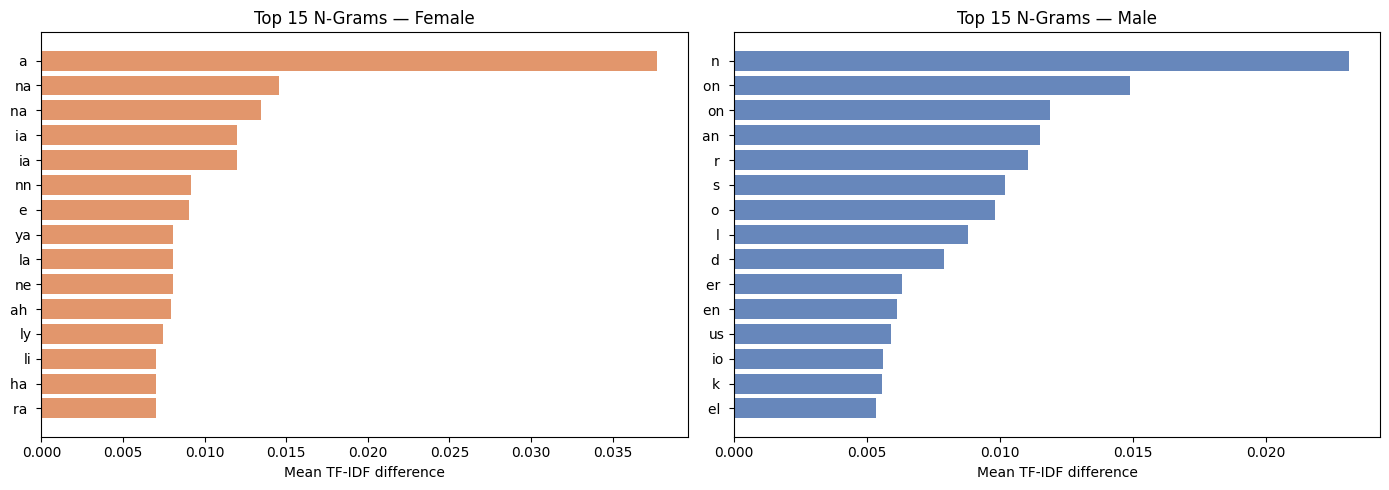

In [5]:
# Visualise top discriminative n-grams
n_show = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, diff, label, color in [
    (axes[0], diff_F, 'Female', '#DD8452'),
    (axes[1], diff_M, 'Male',   '#4C72B0'),
]:
    idx = np.argsort(diff)[-n_show:][::-1]
    ax.barh([feature_names[i] for i in idx], diff[idx], color=color, alpha=0.85)
    ax.set_title(f'Top {n_show} N-Grams — {label}')
    ax.set_xlabel('Mean TF-IDF difference')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'docs', 'gender_ngram_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## A3. Train / Test Split

In [6]:
X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(
    X_gender, labels, test_size=0.20, random_state=RANDOM_SEED, stratify=labels
)
print(f'Train: {X_g_train.shape[0]:,}  |  Test: {X_g_test.shape[0]:,}')

Train: 81,070  |  Test: 20,268


## A4. Train LightGBM — Gender

In [7]:
# LightGBM natively handles sparse CSR matrices — no conversion needed
lgbm_gender = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.08,
    max_depth=8,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1,
)

# Early stopping: use 10% of training data as a validation set
X_g_tr, X_g_val, y_g_tr, y_g_val = train_test_split(
    X_g_train, y_g_train, test_size=0.10, random_state=RANDOM_SEED, stratify=y_g_train
)

lgbm_gender.fit(
    X_g_tr, y_g_tr,
    eval_set=[(X_g_val, y_g_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=50),
    ],
)

y_g_pred = lgbm_gender.predict(X_g_test)
lgbm_gender_acc = accuracy_score(y_g_test, y_g_pred)
print(f'\nLightGBM Gender — Test Accuracy: {lgbm_gender_acc:.4f}')
print(f'Best iteration : {lgbm_gender.best_iteration_}')

[50]	valid_0's binary_logloss: 0.365362
[100]	valid_0's binary_logloss: 0.339191
[150]	valid_0's binary_logloss: 0.327394
[200]	valid_0's binary_logloss: 0.319325
[250]	valid_0's binary_logloss: 0.313174
[300]	valid_0's binary_logloss: 0.308095
[350]	valid_0's binary_logloss: 0.304181
[400]	valid_0's binary_logloss: 0.300894
[450]	valid_0's binary_logloss: 0.298962
[500]	valid_0's binary_logloss: 0.296514

LightGBM Gender — Test Accuracy: 0.8790
Best iteration : 500


## A5. Baseline Comparison — RF (letter counts) vs LightGBM (TF-IDF n-grams)

In [8]:
# Re-build baseline letter-frequency features on the same split for a fair comparison
LETTERS = list('abcdefghijklmnopqrstuvwxyz')

def letter_features(names_array):
    return np.array([[n.count(ch) for ch in LETTERS] for n in names_array])

# Retrieve original name strings for the same train/test indices
# (we need to re-split from the raw names array to get the same partition)
names_train, names_test, y_base_train, y_base_test = train_test_split(
    names, labels, test_size=0.20, random_state=RANDOM_SEED, stratify=labels
)

X_base_train = letter_features(names_train)
X_base_test  = letter_features(names_test)

rf_baseline = RandomForestClassifier(
    n_estimators=200, max_depth=20, random_state=RANDOM_SEED, n_jobs=-1
)
rf_baseline.fit(X_base_train, y_base_train)
rf_acc = accuracy_score(y_base_test, rf_baseline.predict(X_base_test))
print(f'Baseline RF (letter counts)       : {rf_acc:.4f}')
print(f'LightGBM   (TF-IDF n-grams)       : {lgbm_gender_acc:.4f}')
print(f'Improvement                        : +{(lgbm_gender_acc - rf_acc)*100:.2f} pp')

Baseline RF (letter counts)       : 0.7711
LightGBM   (TF-IDF n-grams)       : 0.8790
Improvement                        : +10.79 pp


In [9]:
print('=== LightGBM Gender — Classification Report ===')
print(classification_report(y_g_test, y_g_pred, target_names=['F', 'M']))

=== LightGBM Gender — Classification Report ===
              precision    recall  f1-score   support

           F       0.91      0.90      0.90     12750
           M       0.84      0.84      0.84      7518

    accuracy                           0.88     20268
   macro avg       0.87      0.87      0.87     20268
weighted avg       0.88      0.88      0.88     20268



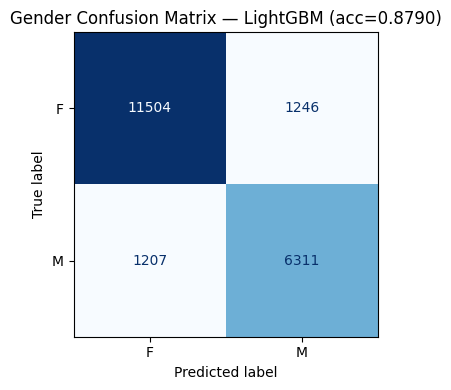

In [10]:
cm = confusion_matrix(y_g_test, y_g_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['F', 'M'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Gender Confusion Matrix — LightGBM (acc={lgbm_gender_acc:.4f})')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'docs', 'gender_lgbm_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## A6. Cross-Validation — LightGBM Gender

In [11]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

# Use a faster estimator count for CV (no early stopping)
lgbm_gender_cv = lgb.LGBMClassifier(
    n_estimators=lgbm_gender.best_iteration_ or 300,
    learning_rate=0.08,
    max_depth=8,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1,
)

cv_scores = cross_val_score(
    lgbm_gender_cv, X_gender, labels,
    cv=cv, scoring='accuracy', n_jobs=-1
)
print(f'10-Fold CV Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Fold scores         : {cv_scores.round(4)}')

10-Fold CV Accuracy : 0.8818 ± 0.0031
Fold scores         : [0.8815 0.8867 0.8859 0.8808 0.8818 0.8837 0.8798 0.883  0.8756 0.8789]


## A7. Save Gender Artefacts

In [12]:
vec_path   = os.path.join(MODELS_DIR, 'gender_tfidf_vectorizer.pkl')
model_path = os.path.join(MODELS_DIR, 'gender_lgbm_model.pkl')

joblib.dump(gender_vectorizer, vec_path)
joblib.dump(lgbm_gender,       model_path)

print(f'Vectorizer saved : {vec_path}')
print(f'Model saved      : {model_path}')

Vectorizer saved : /Volumes/Local Disk/CBBM Momin/NameDemographics-ML/models/gender_tfidf_vectorizer.pkl
Model saved      : /Volumes/Local Disk/CBBM Momin/NameDemographics-ML/models/gender_lgbm_model.pkl


---
# Part B — Race Prediction

## B1. Load Race Data

In [13]:
race_df = pd.read_csv(os.path.join(PROCESSED, 'Race_last_name.csv'))
race_df.columns = [c.strip() for c in race_df.columns]

surname_col = race_df.columns[0]
race_col    = race_df.columns[1]

race_df = race_df.dropna(subset=[surname_col, race_col])
race_df[surname_col] = race_df[surname_col].str.lower().str.strip()

print(f'Rows: {len(race_df):,}')
print('\nClass distribution:')
race_counts = race_df[race_col].value_counts()
print(race_counts)

Rows: 162,251

Class distribution:
white             133229
hispanic           11158
asian               9348
black               7828
americanindian       688
Name: Race, dtype: int64


## B2. Class Imbalance Analysis

In [14]:
# Compute class weights to handle the 82% white majority
from sklearn.utils.class_weight import compute_class_weight

le = LabelEncoder()
race_labels_enc = le.fit_transform(race_df[race_col])
classes = le.classes_

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(classes)),
    y=race_labels_enc
)
class_weight_dict = dict(enumerate(class_weights))

print('Classes and computed weights:')
for cls, w in zip(classes, class_weights):
    print(f'  {cls:<18} weight = {w:.3f}')

Classes and computed weights:
  americanindian     weight = 47.166
  asian              weight = 3.471
  black              weight = 4.145
  hispanic           weight = 2.908
  white              weight = 0.244


## B3. Character N-Gram TF-IDF Features — Race

In [15]:
# Surnames benefit from slightly larger n-grams than first names
# because they tend to be longer and carry ethnic morphological patterns
# (e.g., "-ski", "-ez", "-son", "-berg")
race_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),      # up to 5-grams for surnames
    max_features=12000,
    min_df=2,
    sublinear_tf=True,
)

surnames      = race_df[surname_col].values
race_labels   = race_df[race_col].values

X_race = race_vectorizer.fit_transform(surnames)

print(f'Feature matrix  : {X_race.shape}  (sparse)')
print(f'Non-zero entries: {X_race.nnz:,}')

Feature matrix  : (162251, 12000)  (sparse)
Non-zero entries: 3,097,502


In [16]:
# Top n-grams per race class
race_feature_names = race_vectorizer.get_feature_names_out()
X_race_dense       = X_race.toarray()

print(f'{"Class":<18} Top 10 discriminative n-grams')
print('-' * 80)
for cls in classes:
    mask      = race_labels == cls
    mask_rest = ~mask
    mean_cls  = X_race_dense[mask].mean(axis=0)
    mean_rest = X_race_dense[mask_rest].mean(axis=0)
    diff      = mean_cls - mean_rest
    top10     = [race_feature_names[i] for i in np.argsort(diff)[-10:][::-1]]
    print(f'{cls:<18} {top10}')

Class              Top 10 discriminative n-grams
--------------------------------------------------------------------------------
americanindian     ['e ', 'ie ', 'ea', 'it', 'ie', 'bi', 'white', 'hite', 'hi', 'bear']
asian              ['a ', 'i ', 'an', 'ka', 'na', 'ra', 'ha', 'sa', 'u ', 'ya']
black              ['e ', 's ', 'on ', 'on', 'y ', ' a', 'u ', ' o', 'ie ', 'ea']
hispanic           ['a ', 'ez', 'o ', 'z ', 'ez ', 'ca', 'ar', 'al', ' a', ' c']
white              ['er ', 'er', 'r ', 'k ', 'sk', 'ck', 'sch', 'ke', 'sc', 'ge']


## B4. Train / Test Split — Race

In [17]:
X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
    X_race, race_labels_enc,
    test_size=0.20, random_state=RANDOM_SEED, stratify=race_labels_enc
)
print(f'Train: {X_r_train.shape[0]:,}  |  Test: {X_r_test.shape[0]:,}')

Train: 129,800  |  Test: 32,451


## B5. Train LightGBM — Race (Two Variants)

We train **two versions** to illustrate the accuracy vs fairness tradeoff:

| Variant | `class_weight` | Optimises for |
|---|---|---|
| **Unweighted** | `None` | Overall accuracy (comparable to RF baseline) |
| **Balanced** | Computed from class frequencies | Minority-class recall (americanindian, black, asian) |

The RF baseline gets ~83–84% accuracy **without** class weighting — it achieves this by predicting "white" for nearly all borderline cases (since 82% of the data IS white). That inflates overall accuracy but makes the model nearly useless for identifying minority groups.

Choose based on your downstream research question:
- If you need **overall accuracy**: use the unweighted variant
- If you need to **reliably identify non-white surnames**: use the balanced variant

In [24]:
# Common hyperparameters (shared between both variants)
lgbm_params = dict(
    n_estimators=600,
    learning_rate=0.07,
    max_depth=9,
    num_leaves=127,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_alpha=0.05,
    reg_lambda=0.1,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1,
)

# Early-stopping validation split (shared)
X_r_tr, X_r_val, y_r_tr, y_r_val = train_test_split(
    X_r_train, y_r_train, test_size=0.10,
    random_state=RANDOM_SEED, stratify=y_r_train
)

# ── Variant 1: Unweighted (optimise overall accuracy) ─────────────────────────
lgbm_race_uw = lgb.LGBMClassifier(**lgbm_params)

print('Training UNWEIGHTED variant...')
lgbm_race_uw.fit(
    X_r_tr, y_r_tr,
    eval_set=[(X_r_val, y_r_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=40, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)
y_r_pred_uw   = lgbm_race_uw.predict(X_r_test)
lgbm_race_uw_acc = accuracy_score(y_r_test, y_r_pred_uw)
print(f'Unweighted — Test Accuracy: {lgbm_race_uw_acc:.4f}  (best iter: {lgbm_race_uw.best_iteration_})')

# ── Variant 2: Balanced (optimise minority-class recall) ──────────────────────
lgbm_race_bal = lgb.LGBMClassifier(class_weight=class_weight_dict, **lgbm_params)

print('\nTraining BALANCED variant...')
lgbm_race_bal.fit(
    X_r_tr, y_r_tr,
    eval_set=[(X_r_val, y_r_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=40, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)
y_r_pred_bal   = lgbm_race_bal.predict(X_r_test)
lgbm_race_bal_acc = accuracy_score(y_r_test, y_r_pred_bal)
print(f'Balanced   — Test Accuracy: {lgbm_race_bal_acc:.4f}  (best iter: {lgbm_race_bal.best_iteration_})')

# Pick the unweighted variant as the primary "lgbm_race" for fair comparison
lgbm_race     = lgbm_race_uw
y_r_pred      = y_r_pred_uw
lgbm_race_acc = lgbm_race_uw_acc

Training UNWEIGHTED variant...
[100]	valid_0's multi_logloss: 0.455528
[200]	valid_0's multi_logloss: 0.433348
[300]	valid_0's multi_logloss: 0.423838
[400]	valid_0's multi_logloss: 0.418272
[500]	valid_0's multi_logloss: 0.414773
[600]	valid_0's multi_logloss: 0.41257
Unweighted — Test Accuracy: 0.8673  (best iter: 600)

Training BALANCED variant...
[100]	valid_0's multi_logloss: 1.02274
[200]	valid_0's multi_logloss: 0.912209
[300]	valid_0's multi_logloss: 0.850881
[400]	valid_0's multi_logloss: 0.807241
[500]	valid_0's multi_logloss: 0.774507
[600]	valid_0's multi_logloss: 0.748538
Balanced   — Test Accuracy: 0.6950  (best iter: 600)


## B6. Baseline Comparison — RF vs LightGBM (unweighted) vs LightGBM (balanced)

In [25]:
# Baseline race RF (letter counts, no class weighting)
surnames_train, surnames_test, y_rb_train, y_rb_test = train_test_split(
    surnames, race_labels_enc,
    test_size=0.20, random_state=RANDOM_SEED, stratify=race_labels_enc
)

X_rb_train = letter_features(surnames_train)
X_rb_test  = letter_features(surnames_test)

rf_race_baseline = RandomForestClassifier(
    n_estimators=200, max_depth=20, random_state=RANDOM_SEED, n_jobs=-1
)
rf_race_baseline.fit(X_rb_train, y_rb_train)
rf_race_acc = accuracy_score(y_rb_test, rf_race_baseline.predict(X_rb_test))

print('='*65)
print(f'{"Model":<38} {"Accuracy":>10}')
print('-'*65)
print(f'{"Baseline RF (letter counts)":<38} {rf_race_acc:>10.4f}')
print(f'{"LightGBM TF-IDF (unweighted)":<38} {lgbm_race_uw_acc:>10.4f}  ← fair comparison')
print(f'{"LightGBM TF-IDF (balanced)":<38} {lgbm_race_bal_acc:>10.4f}  ← better minority recall')
print('='*65)
print(f'\nUnweighted improvement over RF: +{(lgbm_race_uw_acc - rf_race_acc)*100:.2f} pp')
print(f'Balanced trades {(rf_race_acc - lgbm_race_bal_acc)*100:.1f} pp overall accuracy for minority recall')

Model                                    Accuracy
-----------------------------------------------------------------
Baseline RF (letter counts)                0.8382
LightGBM TF-IDF (unweighted)               0.8673  ← fair comparison
LightGBM TF-IDF (balanced)                 0.6950  ← better minority recall

Unweighted improvement over RF: +2.91 pp
Balanced trades 14.3 pp overall accuracy for minority recall


In [26]:
print('='*65)
print('UNWEIGHTED — Classification Report')
print('='*65)
print(classification_report(y_r_test, y_r_pred_uw, target_names=classes))

print('\n')
print('='*65)
print('BALANCED — Classification Report')
print('='*65)
print(classification_report(y_r_test, y_r_pred_bal, target_names=classes))

print('\n')
print('='*65)
print('RF BASELINE — Classification Report')
print('='*65)
y_rb_pred = rf_race_baseline.predict(X_rb_test)
print(classification_report(y_rb_test, y_rb_pred, target_names=classes))

UNWEIGHTED — Classification Report
                precision    recall  f1-score   support

americanindian       0.69      0.07      0.12       137
         asian       0.74      0.34      0.46      1870
         black       0.73      0.06      0.11      1566
      hispanic       0.78      0.49      0.60      2232
         white       0.88      0.99      0.93     26646

      accuracy                           0.87     32451
     macro avg       0.76      0.39      0.44     32451
  weighted avg       0.85      0.87      0.84     32451



BALANCED — Classification Report
                precision    recall  f1-score   support

americanindian       0.13      0.26      0.17       137
         asian       0.36      0.67      0.47      1870
         black       0.16      0.49      0.24      1566
      hispanic       0.43      0.80      0.56      2232
         white       0.96      0.70      0.81     26646

      accuracy                           0.70     32451
     macro avg       0.41    

In [27]:
# Per-class recall comparison — this is the key table
cm_rf  = confusion_matrix(y_rb_test, y_rb_pred)
cm_uw  = confusion_matrix(y_r_test, y_r_pred_uw)
cm_bal = confusion_matrix(y_r_test, y_r_pred_bal)

recall_rf  = cm_rf.diagonal()  / cm_rf.sum(axis=1)
recall_uw  = cm_uw.diagonal()  / cm_uw.sum(axis=1)
recall_bal = cm_bal.diagonal() / cm_bal.sum(axis=1)

print(f'{"Class":<18} {"RF Recall":>10} {"LGBM(uw)":>10} {"LGBM(bal)":>10}')
print('-' * 55)
for i, cls in enumerate(classes):
    print(f'{cls:<18} {recall_rf[i]:>10.4f} {recall_uw[i]:>10.4f} {recall_bal[i]:>10.4f}')

print('-' * 55)
print(f'{"Overall Accuracy":<18} {rf_race_acc:>10.4f} {lgbm_race_uw_acc:>10.4f} {lgbm_race_bal_acc:>10.4f}')
print(f'{"Macro Avg Recall":<18} {recall_rf.mean():>10.4f} {recall_uw.mean():>10.4f} {recall_bal.mean():>10.4f}')

Class               RF Recall   LGBM(uw)  LGBM(bal)
-------------------------------------------------------
americanindian         0.0000     0.0657     0.2628
asian                  0.1128     0.3369     0.6743
black                  0.0109     0.0575     0.4891
hispanic               0.1994     0.4857     0.8006
white                  0.9955     0.9882     0.7020
-------------------------------------------------------
Overall Accuracy       0.8382     0.8673     0.6950
Macro Avg Recall       0.2637     0.3868     0.5858


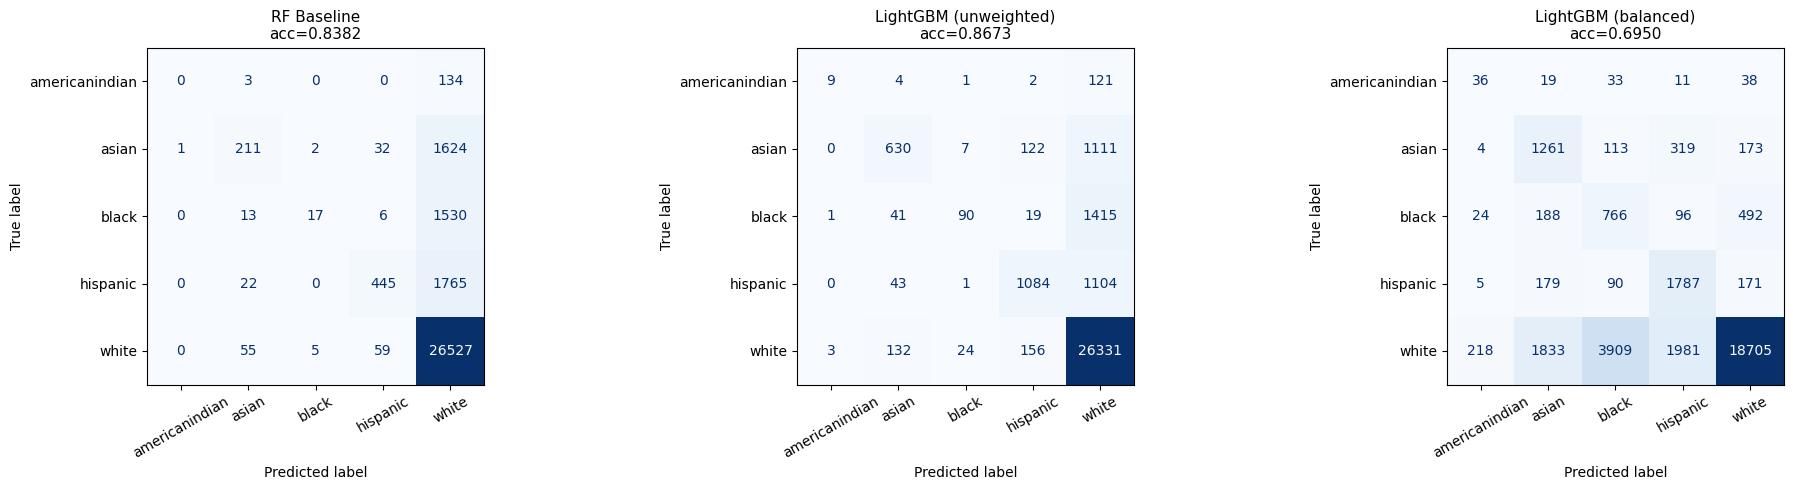

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, cm, title, acc in [
    (axes[0], cm_rf,  'RF Baseline',          rf_race_acc),
    (axes[1], cm_uw,  'LightGBM (unweighted)', lgbm_race_uw_acc),
    (axes[2], cm_bal, 'LightGBM (balanced)',   lgbm_race_bal_acc),
]:
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(f'{title}\nacc={acc:.4f}', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'docs', 'race_all_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## B7. Cross-Validation — LightGBM Race

In [ ]:
lgbm_race_cv = lgb.LGBMClassifier(
    n_estimators=lgbm_race_uw.best_iteration_ or 400,
    learning_rate=0.07,
    max_depth=9,
    num_leaves=127,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_alpha=0.05,
    reg_lambda=0.1,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1,
)

cv_scores_race = cross_val_score(
    lgbm_race_cv, X_race, race_labels_enc,
    cv=cv, scoring='accuracy', n_jobs=-1
)
print(f'10-Fold CV Accuracy (unweighted): {cv_scores_race.mean():.4f} ± {cv_scores_race.std():.4f}')
print(f'Fold scores                     : {cv_scores_race.round(4)}')

## B8. Save Race Artefacts

In [29]:
race_vec_path    = os.path.join(MODELS_DIR, 'race_tfidf_vectorizer.pkl')
race_model_path  = os.path.join(MODELS_DIR, 'race_lgbm_model.pkl')
race_bal_path    = os.path.join(MODELS_DIR, 'race_lgbm_model_balanced.pkl')
race_le_path     = os.path.join(MODELS_DIR, 'race_label_encoder.pkl')

joblib.dump(race_vectorizer, race_vec_path)
joblib.dump(lgbm_race_uw,    race_model_path)       # primary: unweighted
joblib.dump(lgbm_race_bal,   race_bal_path)          # alternative: balanced
joblib.dump(le,              race_le_path)

print(f'Race vectorizer saved       : {race_vec_path}')
print(f'Race model (unweighted)     : {race_model_path}')
print(f'Race model (balanced)       : {race_bal_path}')
print(f'Label encoder updated       : {race_le_path}')

Race vectorizer saved       : /Volumes/Local Disk/CBBM Momin/NameDemographics-ML/models/race_tfidf_vectorizer.pkl
Race model (unweighted)     : /Volumes/Local Disk/CBBM Momin/NameDemographics-ML/models/race_lgbm_model.pkl
Race model (balanced)       : /Volumes/Local Disk/CBBM Momin/NameDemographics-ML/models/race_lgbm_model_balanced.pkl
Label encoder updated       : /Volumes/Local Disk/CBBM Momin/NameDemographics-ML/models/race_label_encoder.pkl


---
# Part C — Side-by-Side Summary

In [30]:
summary = pd.DataFrame({
    'Task':      ['Gender', 'Gender',
                  'Race',   'Race',    'Race'],
    'Model':     ['RF (letter counts)', 'LightGBM (TF-IDF n-grams)',
                  'RF (letter counts)', 'LightGBM unweighted', 'LightGBM balanced'],
    'Features':  [26, X_gender.shape[1],
                  26, X_race.shape[1], X_race.shape[1]],
    'Accuracy':  [
        round(rf_acc, 4),
        round(lgbm_gender_acc, 4),
        round(rf_race_acc, 4),
        round(lgbm_race_uw_acc, 4),
        round(lgbm_race_bal_acc, 4),
    ],
    'Macro Recall': [
        '—', '—',
        f'{recall_rf.mean():.4f}',
        f'{recall_uw.mean():.4f}',
        f'{recall_bal.mean():.4f}',
    ],
})
print(summary.to_string(index=False))
print('\n→ For race, "Macro Recall" is a better metric than accuracy on imbalanced data.')

  Task                     Model  Features  Accuracy Macro Recall
Gender        RF (letter counts)        26    0.7711            —
Gender LightGBM (TF-IDF n-grams)      8000    0.8790            —
  Race        RF (letter counts)        26    0.8382       0.2637
  Race       LightGBM unweighted     12000    0.8673       0.3868
  Race         LightGBM balanced     12000    0.6950       0.5858

→ For race, "Macro Recall" is a better metric than accuracy on imbalanced data.


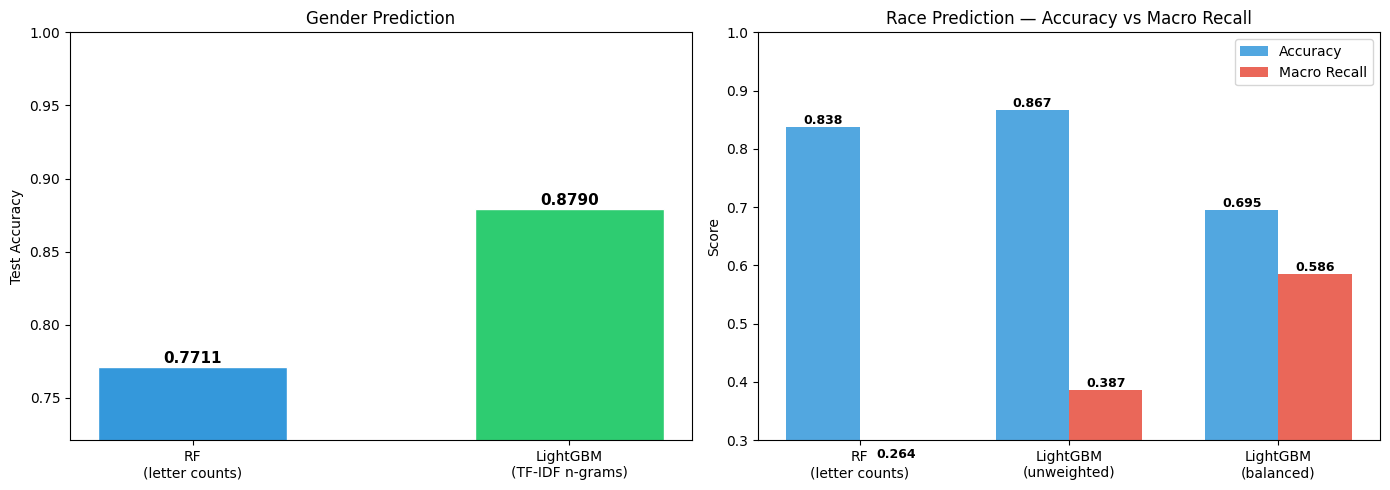

In [31]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Gender (simple: RF vs LightGBM)
ax = axes[0]
bars = ax.bar(
    ['RF\n(letter counts)', 'LightGBM\n(TF-IDF n-grams)'],
    [rf_acc, lgbm_gender_acc],
    color=['#3498db', '#2ecc71'], width=0.5, edgecolor='white',
)
ax.set_ylim(max(0, min(rf_acc, lgbm_gender_acc) - 0.05), 1.0)
ax.set_title('Gender Prediction', fontsize=12)
ax.set_ylabel('Test Accuracy')
for bar, val in zip(bars, [rf_acc, lgbm_gender_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# — Race (three-way: RF vs LGBM-unweighted vs LGBM-balanced)
ax = axes[1]
labels = ['RF\n(letter counts)', 'LightGBM\n(unweighted)', 'LightGBM\n(balanced)']
accs   = [rf_race_acc, lgbm_race_uw_acc, lgbm_race_bal_acc]
macros = [recall_rf.mean(), recall_uw.mean(), recall_bal.mean()]

x = np.arange(len(labels))
w = 0.35
bars1 = ax.bar(x - w/2, accs,   w, label='Accuracy',    color='#3498db', alpha=0.85)
bars2 = ax.bar(x + w/2, macros, w, label='Macro Recall', color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.3, 1.0)
ax.set_title('Race Prediction — Accuracy vs Macro Recall', fontsize=12)
ax.set_ylabel('Score')
ax.legend()
for bar, val in zip(list(bars1) + list(bars2), accs + macros):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'docs', 'lgbm_vs_rf_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
# Part D — Quick Inference Test with New Models

In [32]:
# Load saved artefacts
g_vec   = joblib.load(os.path.join(MODELS_DIR, 'gender_tfidf_vectorizer.pkl'))
g_model = joblib.load(os.path.join(MODELS_DIR, 'gender_lgbm_model.pkl'))
r_vec   = joblib.load(os.path.join(MODELS_DIR, 'race_tfidf_vectorizer.pkl'))
r_model = joblib.load(os.path.join(MODELS_DIR, 'race_lgbm_model.pkl'))
r_le    = joblib.load(os.path.join(MODELS_DIR, 'race_label_encoder.pkl'))

def predict_lgbm(first_name: str, last_name: str) -> dict:
    fn = first_name.lower()
    ln = last_name.lower()

    g_feat  = g_vec.transform([fn])
    g_label = g_model.predict(g_feat)[0]
    g_prob  = g_model.predict_proba(g_feat).max()

    r_feat  = r_vec.transform([ln])
    r_idx   = r_model.predict(r_feat)[0]
    r_label = r_le.inverse_transform([r_idx])[0]
    r_probs = dict(zip(r_le.classes_, r_model.predict_proba(r_feat)[0].round(4)))

    return {
        'gender': g_label, 'gender_conf': round(float(g_prob), 4),
        'race':   r_label, 'race_probs':  r_probs,
    }


test_names = [
    ('Mary',     'Smith'),
    ('James',    'Johnson'),
    ('Maria',    'Garcia'),
    ('David',    'Williams'),
    ('Jennifer', 'Kim'),
    ('Carlos',   'Rodriguez'),
    ('Wei',      'Chen'),
    ('Momin',    'Khondhaker'),
]

print(f'{"Name":<22} {"Gender":<8} {"Conf":<7} {"Race"}')
print('-' * 65)
for fn, ln in test_names:
    r = predict_lgbm(fn, ln)
    print(f'{fn+" "+ln:<22} {r["gender"]:<8} {r["gender_conf"]:<7.4f} {r["race"]}')

Name                   Gender   Conf    Race
-----------------------------------------------------------------
Mary Smith             F        0.7649  white
James Johnson          M        0.8899  white
Maria Garcia           F        0.9833  hispanic
David Williams         M        0.8989  black
Jennifer Kim           F        0.8916  asian
Carlos Rodriguez       M        0.8070  hispanic
Wei Chen               F        0.6086  asian
Momin Khondhaker       M        0.7123  white
